In [7]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
np.set_printoptions(threshold=np.inf)

schemes = ['draws/DATA/Zeropod/Zeropod/multipods_W5/new_schedule4/ppt_16_bppn_5120', 'Zeropod/singlepod_W5/new_schedule4/W5_incast/ost_off/ppt_16_topk_16', ]
schemes_label = ["on", "off",]
schemes = ['Zeropod/multipods_W5/new_schedule4/W5_19/ppt_32_bppn_320_topk_16', 'dctcp/multipods_W5/W5_19', ] #19
schemes = ['Zeropod/multipods_W5/new_schedule4/ppt_32_bppn_320', 'Zeropod/multipods_W5/new_schedule4/W5_19/ppt_32_bppn_320_topk_16', 'Zeropod/multipods_W5/new_schedule4/W5_95/ppt_32_bppn_320_topk_16', 'Zeropod/multipods_W5/new_schedule4/W5_99/ppt_32_bppn_320_topk_16', ] #19
# schemes = ['Zeropod/multipods_W5/new_schedule4/ppt_32_bppn_320', 'dctcp/multipods_W5/W5'] #28
# schemes = ['dctcp/multipods_W5/permutation', 'Zeropod/multipods_W5/new_schedule4/permutation/ppt_32_bppn_320_topk_16']

schemes = ['Zeropod/multipods_W5/new_schedule5/W5/ppt_32_bppn_320_topk_16', 'dctcp/multipods_W5/permutation', 'Zeropod/multipods_W5/new_schedule4/permutation/ppt_32_bppn_320_topk_16', ]
schemes = ['Zeropod/multipods_W5/new_schedule5/W5/ppt_32_bppn_320_topk_16']
schemes = ['Zeropod/multipods_W5/new_schedule4/ppt_32_bppn_320_topk_16', 'Zeropod/multipods_W5/new_schedule5_wrong/W5/ppt_32_bppn_320_topk_16', 'Zeropod/multipods_W5/new_schedule5.4/W5/ppt_32_bppn_320_topk_16',]
schemes = ['Zeropod/multipods_W5/select_core_according_to_flow_size_8_8_supress_c2e/W4_28_lower_ost/ppt_32_bppn_320_topk_16']
schemes = ['../../DATA/125_19']

# schemes_label = ["zeropod", "dctcp"]

# schemes = ['Zeropod/singlepod_W5/new_schedule4/W5_incast/ppt_16']
# schemes_label = ['singlepod']
# schemes_label = ["2x_recdelay_10_up_40"]
# schemes = ['/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40']
# reverse the schemes
# schemes = schemes[::-1]
# schemes = schemes[1:5]
# workloads = ["W5_0.1", "W5_0.25", "W5_0.5", "W5_0.75", "W5_1"]
# labels = ["10", "25", "50", "75", "100"]
# workloads = ["W5_0.1"]
# labels = ["10"]

workloads = ["permutation_size1000"]
labels = ["1000"]
workloads = ["W5_1"]
labels = ["100"]

# workloads = ["W4_0.1", "W4_0.25", "W4_0.5", "W4_0.75", "W4_1"]
# labels = ["10", "25", "50", "75", "100"]
# workloads = ["W4_0.1"]
# labels = ["10"]

metrics = ['FCT', 'GOODPUT']

# labels = ['10', '25', '50', '75', '100']
# labels = ['2', '3', '4', '5', '6']

my_figsize = [20, 12]
my_fontsize = 55
colors = ['firebrick', 'darkblue']
WIDTH = 0.03  # the width of the bars
SHORT = 100000  # 100KB
LONG = 1000000 # 1MB

data = {}
for scheme in schemes:
    data[scheme] = {}
    for workload in workloads:
        data[scheme][workload] = {}

for scheme in schemes:
    for workload in workloads:
        for metric in metrics:
            file_name = "{scheme}/DATA_{workload}/{metric}.txt".format(scheme=scheme, workload=workload, metric=metric)
            data[scheme][workload][metric] = np.loadtxt(file_name)

for scheme in schemes:
        for workload in workloads:
            data[scheme][workload]['SHORT_IDX'] = data[scheme][workload]['FCT'][:, 4] < SHORT
            data[scheme][workload]['LONG_IDX'] = data[scheme][workload]['FCT'][:, 4] > LONG
            data[scheme][workload]['MIDDLE_IDX'] = (data[scheme][workload]['FCT'][:, 4] >= SHORT) * (data[scheme][workload]['FCT'][:, 4] <= LONG)
            data[scheme][workload]['intra-pod'] = np.trunc(data[scheme][workload]['FCT'][:,2] / 16) == np.trunc(data[scheme][workload]['FCT'][:,3] / 16)
            data[scheme][workload]['inter-pod'] = np.trunc(data[scheme][workload]['FCT'][:,2] / 16) != np.trunc(data[scheme][workload]['FCT'][:,3] / 16)

../../DATA/125_19 W5_1 Zeropod-28-NSDI24 99p FCT: 3.040593452402561
../../DATA/125_19 W5_1 Zeropod-28-NSDI24 80p FCT: 0.3678530694894988
../../DATA/125_19 W5_1 Zeropod-28-NSDI24 50p FCT: 0.09919665470370376
../../DATA/125_19 W5_1 Zeropod-28-NSDI24 99p FCT: 2.598482204124831
../../DATA/125_19 W5_1 Zeropod-28-NSDI24 80p FCT: 0.2886182622376504
../../DATA/125_19 W5_1 Zeropod-28-NSDI24 50p FCT: 0.07321612480615247
../../DATA/125_19 W5_1 Zeropod-28-NSDI24 99p FCT: 2.8011011656642855
../../DATA/125_19 W5_1 Zeropod-28-NSDI24 80p FCT: 0.3225809872544172
../../DATA/125_19 W5_1 Zeropod-28-NSDI24 50p FCT: 0.08353917557424317


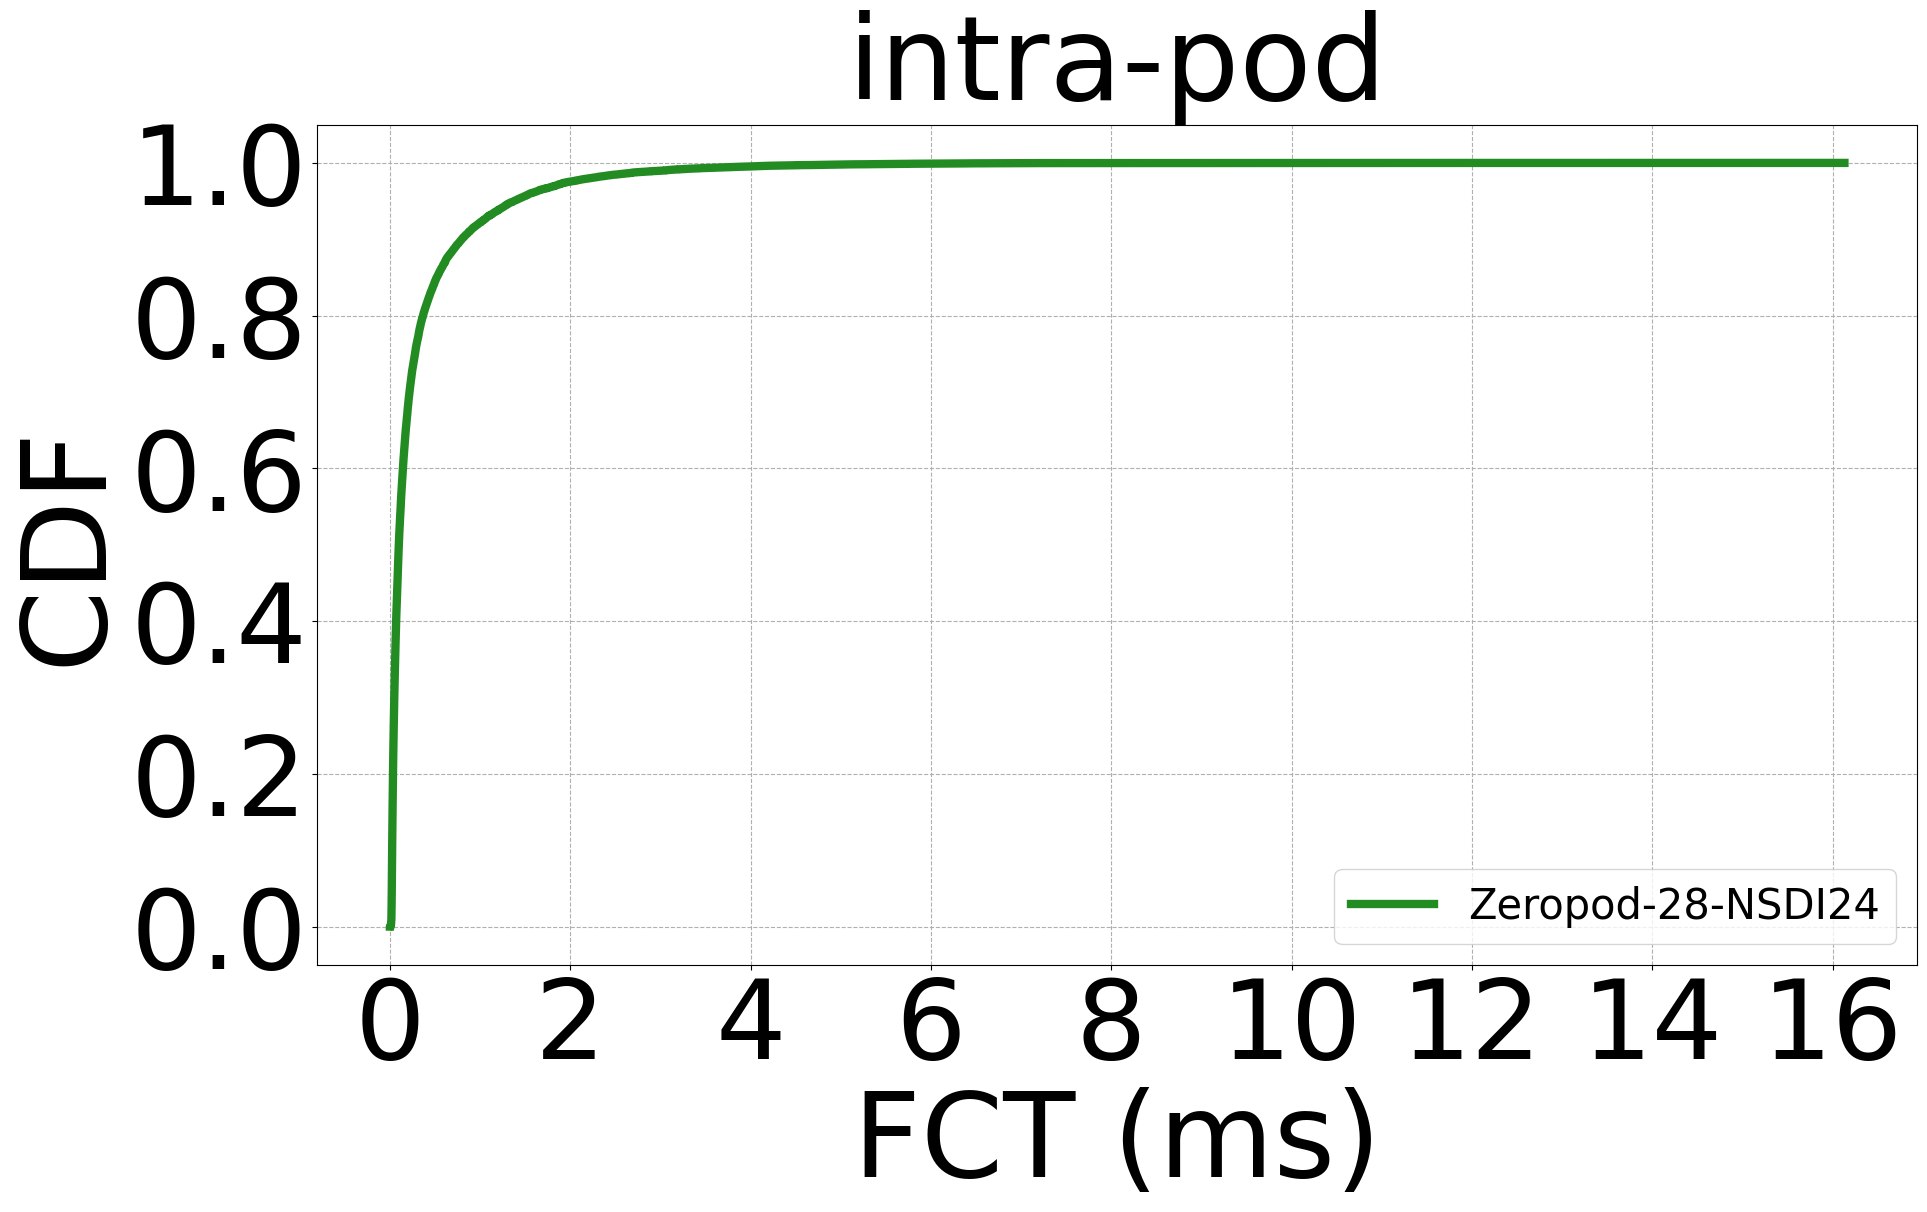

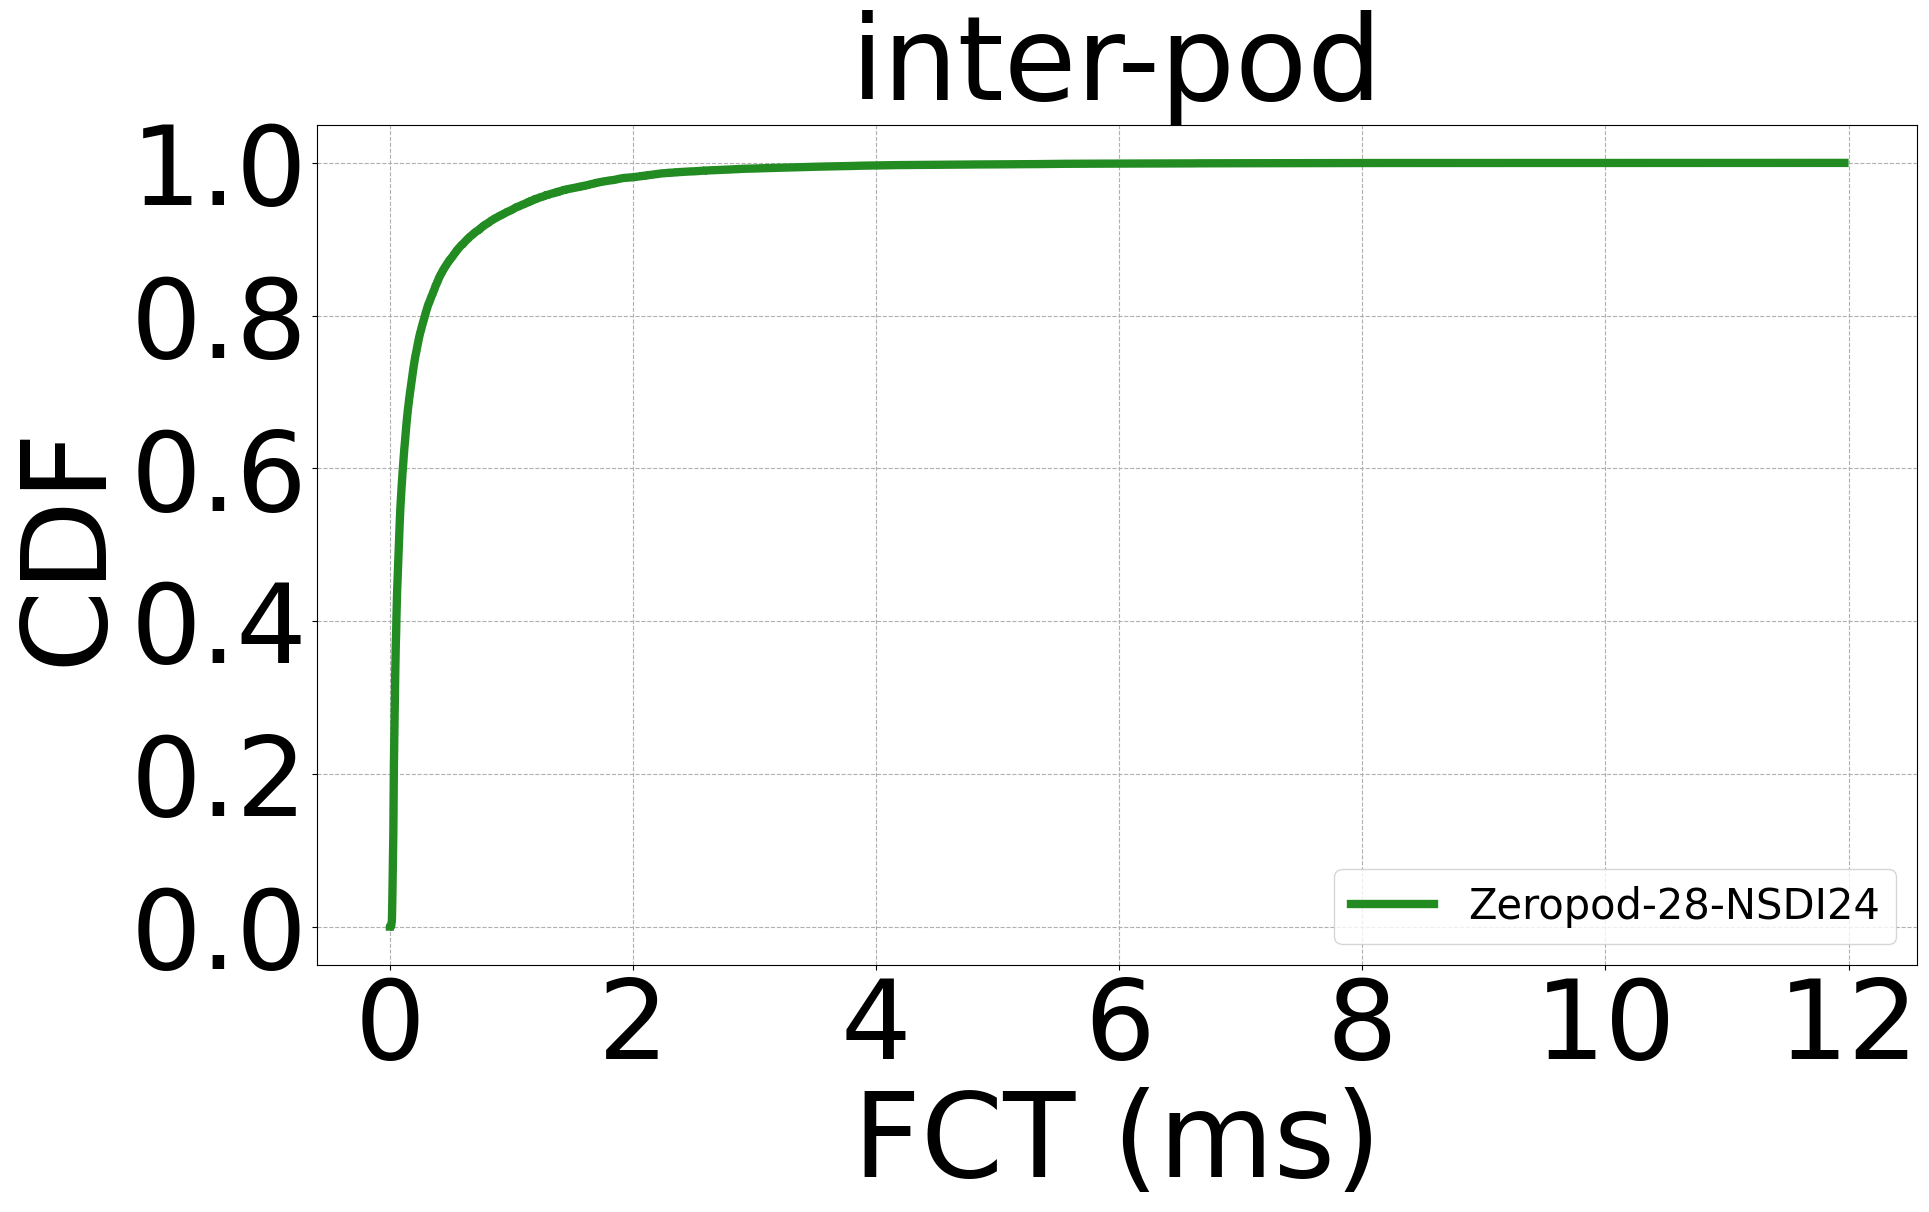

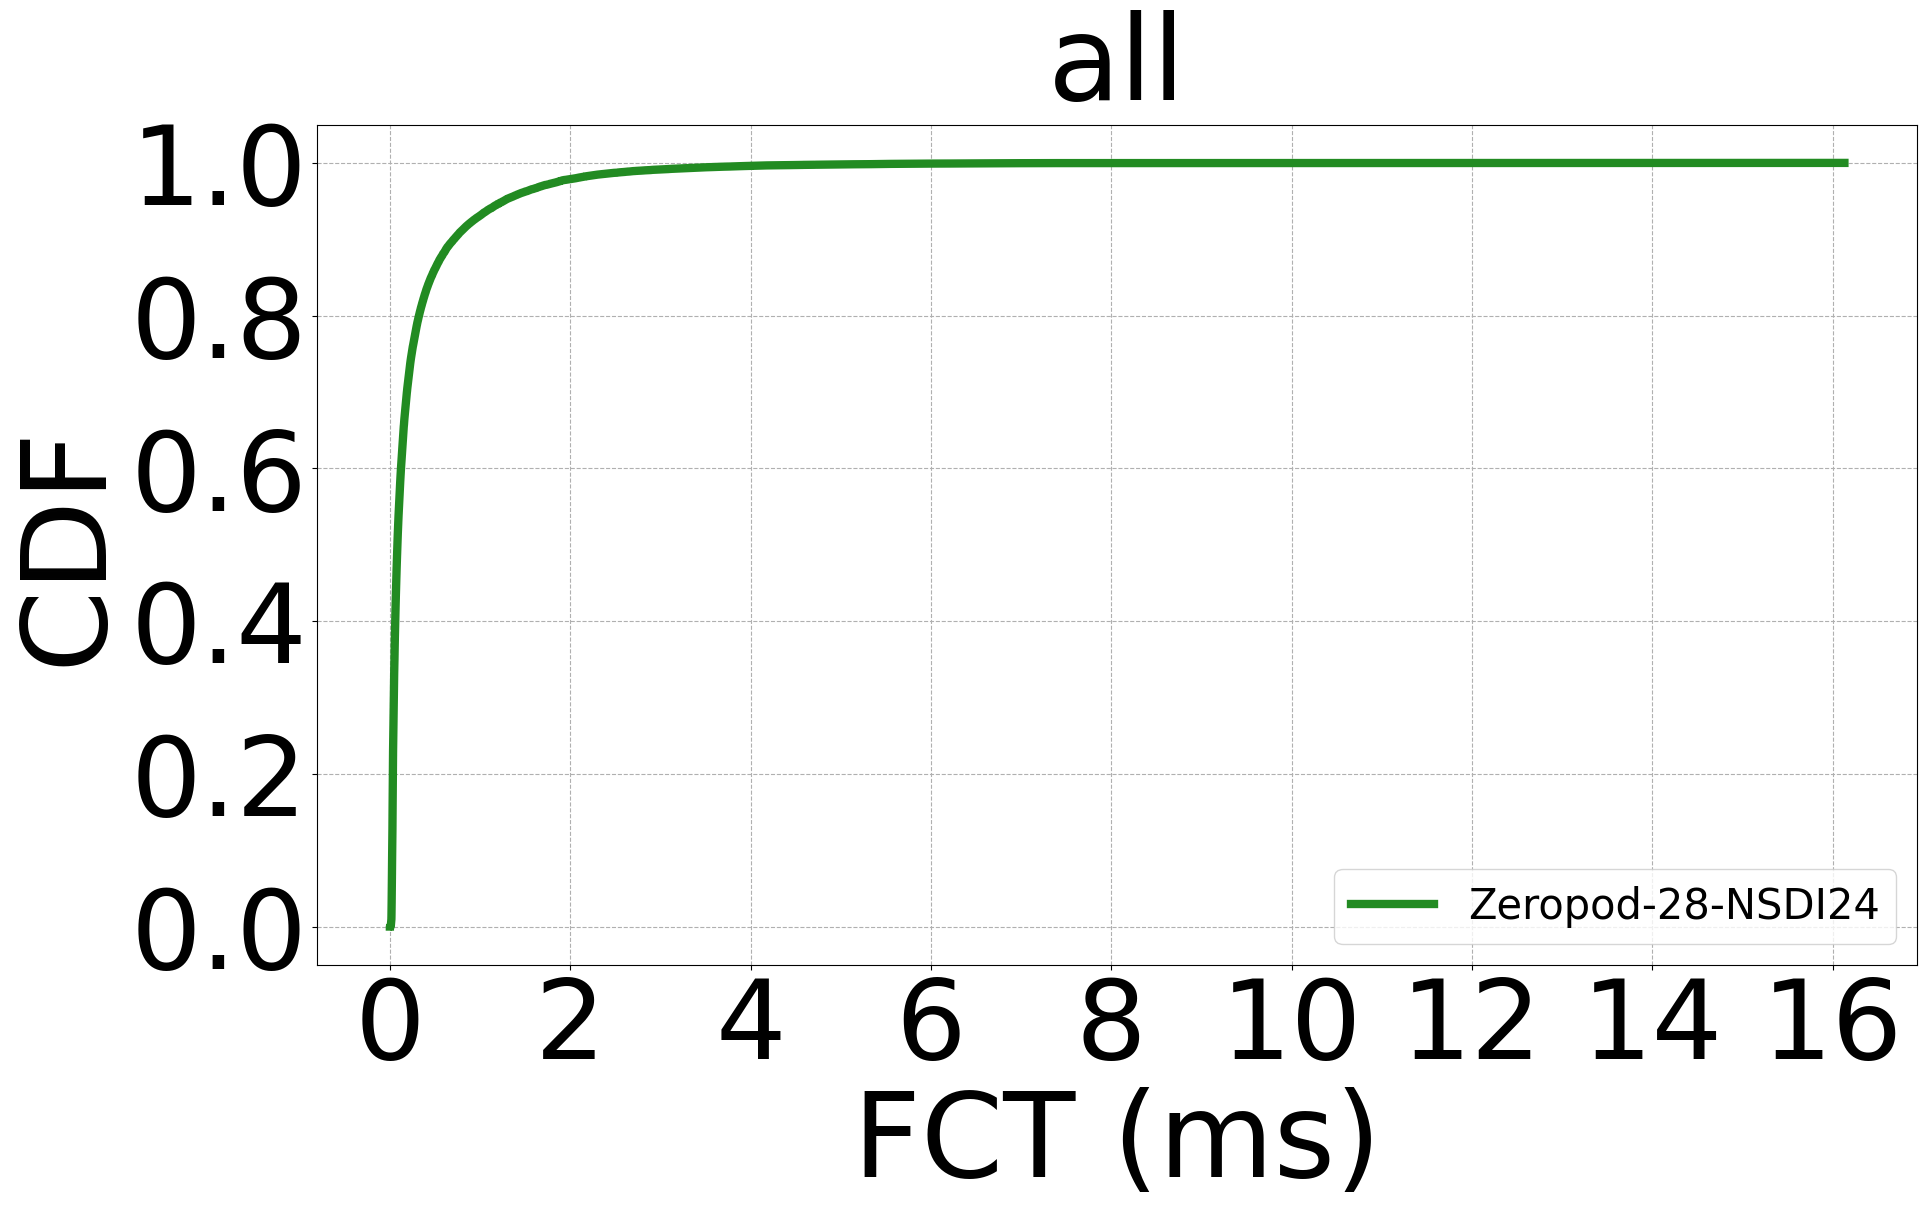

In [8]:
my_fontsize = 85
NUM_BINS = 50000
# colors = ['firebrick', 'darkblue', 'lightgreen', 'green']
colors = ['forestgreen', 'firebrick', 'darkblue', 'darkorange', 'darkorchid', 'lightseagreen', 'darkviolet', 'darkturquoise', 'darkslategray', 'darkgoldenrod', 'darkmagenta']

linestyles = ["solid", "--", "-.", ":"]
# linestyles = ["solid", "solid", "solid", "solid"]
schemes_label = ['Zeropod-28-s4', 'Zeropod-28-s5-wrong', 'Zeropod-28-s5', 'DCTCP', 'Zeropod-28-s5.2', 'Zeropod-28-s5.3', 'DCTCP-28', 'Zeropod-19-s5', 'DCTCP-19']
schemes_label = ['Zeropod-28-NSDI24', 'Zeropod-28-priority', 'Zeropod-28-supress', 'DCTCP', 'Zeropod-28-s5.2', 'Zeropod-28-s5.3', 'DCTCP-28', 'Zeropod-19-s5', 'DCTCP-19']

def get_slowdown_percentile(x, flowsize, slowdown, percent=99):
    index = np.searchsorted(flowsize, x, side='right') - 1
    if index < 0:
        return 0
    else:
        return np.percentile(slowdown[:index+1], percent)

def fct_bar_plot(mode, labels, workload, flow_range='all', pods="all"):
    # fig, axs = plt.subplots(nrows=2, ncols=3, figsize=my_figsize)
    _, ax = plt.subplots(figsize=my_figsize)
    plt.subplots_adjust(left=0.16, right=0.96, bottom=0.2, top=0.9)
    for plot_index, workload in enumerate(workloads):
        # ax = axs[int(plot_index/3), plot_index%3]
        for i, scheme in enumerate(schemes):
            if flow_range == 'Mice':
                idx = data[scheme][workload]['SHORT_IDX']
            elif flow_range == 'Elephant':
                idx = data[scheme][workload]['LONG_IDX']
            elif flow_range == 'middle':
                idx = data[scheme][workload]['MIDDLE_IDX']
            elif flow_range == 'all':
                idx = np.arange(len(data[scheme][workload]['FCT']))

            # available_idx = data[scheme][workload]['FCT'][:, 7] > 0 # 过滤未完成的流
            if pods == "intra-pod":
                idx_xx = data[scheme][workload]['intra-pod']
                idx = idx * idx_xx
            elif pods == "inter-pod":
                idx_xx = data[scheme][workload]['inter-pod']
                idx = idx * idx_xx
            # print(sum(idx_xx))
            # idx_xx = data[scheme][workload]['intra-pod']
            
            # print(sum(idx))
            
            fct = np.array(data[scheme][workload]['FCT'][idx, 7])*1e3
            # print(max(fct))
            # 输出最小的fct及其编号
            # if workload == "W5_0.1" and i == 0:
            #     print(min(fct), np.where(fct == np.min(fct)))
            # counts, bin_edges = np.histogram(fct, bins=NUM_BINS)
            # cdf = np.cumsum(counts)
            # ax.plot(bin_edges[:-1], cdf/len(fct), label=labels[i], linewidth=3, color = colors[i])
            
            # 打印99p FCT
            print(f"{scheme} {workload} {labels[i]} 99p FCT: {np.percentile(fct, 99)}")
            print(f"{scheme} {workload} {labels[i]} 80p FCT: {np.percentile(fct, 80)}")
            print(f"{scheme} {workload} {labels[i]} 50p FCT: {np.percentile(fct, 50)}")
                
            # 打印flow size < 2560的条数
            # print(f"{scheme} {workload} {labels[i]} flow size < 2560: {sum(data[scheme][workload]['FCT'][idx, 4] < 2560)}")
            
            # 计算CDF
            sorted_data = np.sort(fct)
            if workload == "W5_0.1" and i == 0:
                print(sorted_data)
            yvals = np.arange(len(sorted_data))/float(len(sorted_data))
            

            # 绘制CDF
            ax.plot(sorted_data[1:], yvals[1:], label=labels[i], linewidth=6, color = colors[i], linestyle=linestyles[i], alpha=1)
        
        # ax.set_xticks(fontsize=my_fontsize)
        # ax.set_yticks(fontsize=my_fontsize)
        ax.tick_params(axis='both', which='major')
        # ax.set_xscale('log')
        # ax.set_yscale('log')
        
        # ax.set_xlim(0.9, 2)
        ax.grid(True, linestyle='dashed')
        # if plot_index == 3:
        ax.set_xlabel(r'FCT ($\mu$s)', fontsize=my_fontsize)
        ax.set_xlabel(r'FCT (ms)', fontsize=my_fontsize)
        plt.xticks(fontsize=my_fontsize-5)
        plt.yticks(fontsize=my_fontsize-5)

        ax.set_ylabel("CDF", fontsize = my_fontsize)
        ax.set_title(pods, fontsize=my_fontsize)
        # if plot_index == 4:
        ax.legend(ncol=1, loc="lower right", fontsize=30)
        # ax.set_xlim([0, 100])
        # ax.legend(ncol=1, loc="upper right", bbox_to_anchor=(2, 1), fontsize=15)
    # axs[1,2].axis('off')
    

# fct_bar_plot("99p", labels, workloads, flow_range='Mice', pods='multipods')
fct_bar_plot("99p", schemes_label, workloads, flow_range='Mice', pods='intra-pod')
fct_bar_plot("99p", schemes_label, workloads, flow_range='Mice', pods='inter-pod')
fct_bar_plot("99p", schemes_label, workloads, flow_range='Mice', pods='all')
# plt.savefig(f"../FIGS/Zeropod/singlepod/os_off_CDF.pdf")